#### Libraries Import

In [63]:
#Libraries
# requirements.txt contain all libraries used in this project
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [64]:
#Dataset loading
df = pd.read_csv("candy-data.csv")

df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


#### Data Exploration

- dataset is concise, not extensive
- PCA seems great fit to get a general perspective about the data
- dataset contains categorical values (0,1) and some continuous features
- Need to encode categorical values into something machine readable

In [65]:
#Selecting categorical columns
#Sugar and price are already percentage, so no need encoding.

cols_to_encode = [
    "chocolate",
    "fruity",
    "caramel",
    "peanutyalmondy",
    "nougat",
    "crispedricewafer",
    "hard",
    "bar",
    "pluribus"
]

enc_values = df[cols_to_encode]
freq_df = df.copy()

for col in enc_values:
    freq = enc_values[col].value_counts(normalize=True)
    freq_df[col] = freq_df[col].map(freq)

freq_df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,0.435294,0.552941,0.164706,0.835294,0.917647,0.082353,0.823529,0.247059,0.482353,0.732,0.860,66.971725
1,3 Musketeers,0.435294,0.552941,0.835294,0.835294,0.082353,0.917647,0.823529,0.247059,0.482353,0.604,0.511,67.602936
2,One dime,0.564706,0.552941,0.835294,0.835294,0.917647,0.917647,0.823529,0.752941,0.482353,0.011,0.116,32.261086
3,One quarter,0.564706,0.552941,0.835294,0.835294,0.917647,0.917647,0.823529,0.752941,0.482353,0.011,0.511,46.116505
4,Air Heads,0.564706,0.447059,0.835294,0.835294,0.917647,0.917647,0.823529,0.752941,0.482353,0.906,0.511,52.341465


##### PCA data exploration

In [91]:
class PCAFunc:
    def __init__(self, scaler=None, num_comp=2, flip_pca1=False, flip_pca2=False):
        self.scaler = scaler if scaler is not None else StandardScaler()
        self.num_comp = num_comp
        self.flip_pca1 = flip_pca1
        self.flip_pca2 = flip_pca2

        self.pca_model = None
        self.pca_df = None
        self.explained_variance_ratio_ = None
        self.input_cols = None

    def pca(self, input_df, input_cols, include_sugar_price=False):
        self.input_cols = input_cols.copy()

        if include_sugar_price:
            self.input_cols = list(
                dict.fromkeys(input_cols + ["sugarpercent", "pricepercent"])
            )

        X = input_df[self.input_cols]

        #Using StandardScaler to bring all features to same scale
        X_scaled = self.scaler.fit_transform(X)

        self.pca_model = PCA(n_components=self.num_comp)
        pca_values = self.pca_model.fit_transform(X_scaled)

        self.pca_df = pd.DataFrame(
            pca_values,
            columns=[f"PCA{i+1}" for i in range(self.num_comp)],
            index=input_df.index
        )

        if self.flip_pca1:
            self.pca_df["PCA1"] = -self.pca_df["PCA1"]

        if self.flip_pca2:
            self.pca_df["PCA2"] = -self.pca_df["PCA2"]

        for col in ["competitorname", "sugarpercent", "pricepercent", "winpercent"]:
            if col in input_df.columns:
                self.pca_df[col] = input_df[col]

        self.explained_variance_ratio_ = self.pca_model.explained_variance_ratio_

        return self.pca_df, self.explained_variance_ratio_

    def pca_plot(self, use_winpercent_size=False, show_loadings=False, arrow_scale=3):
        pca_df = self.pca_df.copy()

        pca_df["sugar_group"] = pd.qcut(
            pca_df["sugarpercent"],
            q=3,
            labels=["Low sugar", "Medium sugar", "High sugar"]
        )

        shape_map = {
            "Low sugar": "o",
            "Medium sugar": "s",
            "High sugar": "^"
        }

        if use_winpercent_size:
            pca_df["marker_size"] = 50 + (
                (pca_df["winpercent"] - pca_df["winpercent"].min()) /
                (pca_df["winpercent"].max() - pca_df["winpercent"].min())
            ) * 250
        else:
            pca_df["marker_size"] = 90

        plt.figure(figsize=(12, 8))

        for sugar_group, marker in shape_map.items():
            subset = pca_df[pca_df["sugar_group"] == sugar_group]

            scatter = plt.scatter(
                subset["PCA1"],
                subset["PCA2"],
                c=subset["pricepercent"],
                cmap="viridis",
                marker=marker,
                s=subset["marker_size"],
                edgecolor="black",
                alpha=0.85,
                label=sugar_group
            )

        plt.colorbar(scatter, label="Price Percent")

        if show_loadings:
            loadings = self.pca_model.components_.T.copy()

            if self.flip_pca1:
                loadings[:, 0] = -loadings[:, 0]

            if self.flip_pca2:
                loadings[:, 1] = -loadings[:, 1]

            for i, feature in enumerate(self.input_cols):
                plt.arrow(
                    0,
                    0,
                    loadings[i, 0] * arrow_scale,
                    loadings[i, 1] * arrow_scale,
                    color="red",
                    alpha=0.8,
                    head_width=0.08,
                    length_includes_head=True
                )

                plt.text(
                    loadings[i, 0] * arrow_scale * 1.15,
                    loadings[i, 1] * arrow_scale * 1.15,
                    feature,
                    color="red",
                    fontsize=10
                )

            plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
            plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

        plt.xlabel(f"PCA 1 ({self.explained_variance_ratio_[0]:.1%} variance)")
        plt.ylabel(f"PCA 2 ({self.explained_variance_ratio_[1]:.1%} variance)")

        title = "PCA of Candy Features"

        if use_winpercent_size:
            title += "\nMarker size = Win Percent"

        if show_loadings:
            title += " with Loadings"

        plt.title(title)

        plt.legend(title="Sugar Percent Group")
        plt.show()

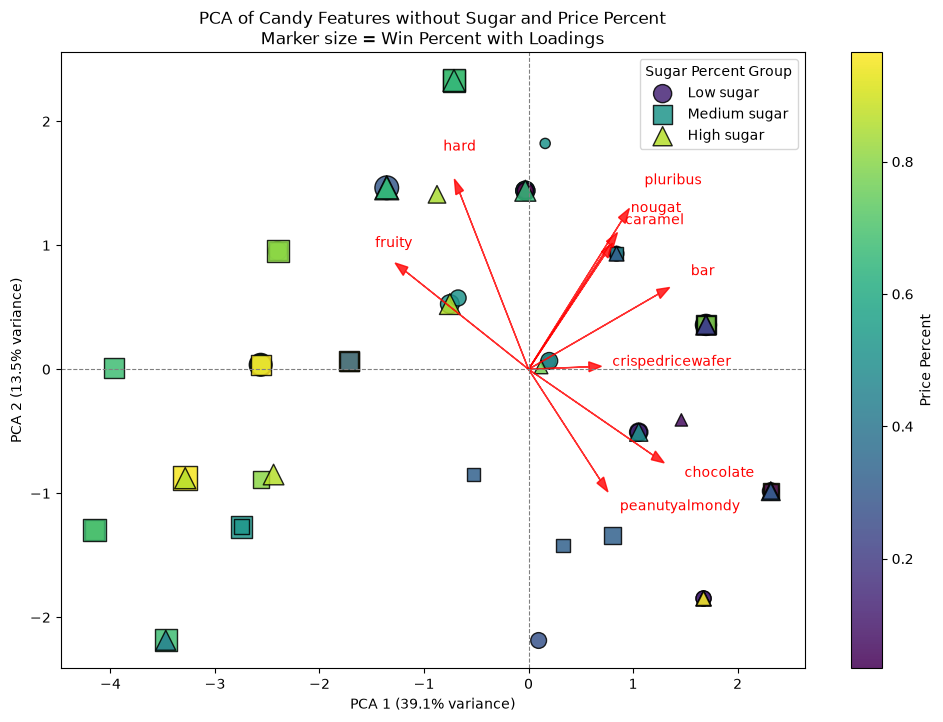

In [88]:
#First PCA without sugar and price
pca_runner = PCAFunc(num_comp=2)

pca_df, explained_variance = pca_runner.pca(
    input_df=freq_df,
    input_cols=cols_to_encode,
    include_sugar_price=False
)

pca_runner.pca_plot(
    use_winpercent_size=True,
    show_loadings=True,
    arrow_scale=3
)

##### PCA including sugar and price

- Since most attributes are categorical, even encoding them as frequencies, most data have similar values thus creating overlap
- Including sugar and price in PCA, which are continuous values spreads the data, creating better visualization

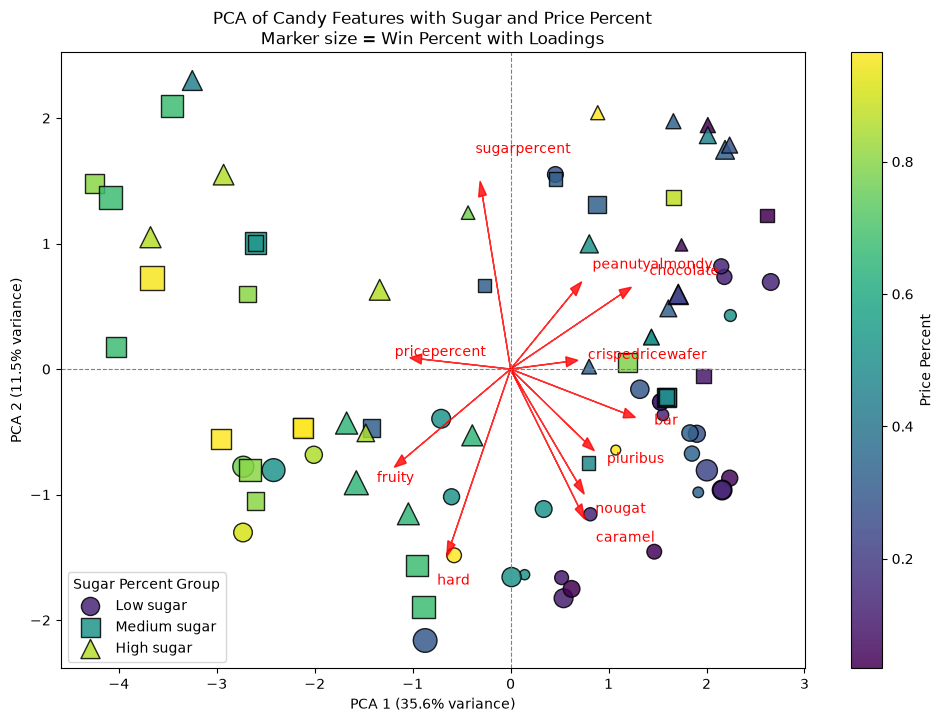

In [90]:
#PCA execution including sugar and price
pca_runner = PCAFunc(num_comp=2)

pca_df, explained_variance = pca_runner.pca(
    input_df=freq_df,
    input_cols=cols_to_encode,
    include_sugar_price=True
)

pca_runner.pca_plot(
    use_winpercent_size=True,
    show_loadings=True,
    arrow_scale=3
)

##### Using Kmeans in order to cluster data

In [39]:
class KMeansCluster:
    def __init__(self, n_clusters=3, random_state=42, n_init=10):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init

        self.kmeans_model = None
        self.cluster_df = None

    def fit(self, pca_df):
        self.cluster_df = pca_df.copy()

        self.kmeans_model = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=self.n_init
        )

        self.cluster_df["cluster"] = self.kmeans_model.fit_predict(
            self.cluster_df[["PCA1", "PCA2"]]
        )

        return self.cluster_df

    def plot(
        self,
        pca_model=None,
        input_cols=None,
        explained_variance_ratio=None,
        show_loadings=False,
        arrow_scale=3,
        use_sugar_shapes=False,
        use_winpercent_size=False
    ):
        if self.cluster_df is None:
            raise ValueError("Run .fit(pca_df) before plotting.")

        if show_loadings and (pca_model is None or input_cols is None):
            raise ValueError("To show loadings, provide pca_model and input_cols.")

        plot_df = self.cluster_df.copy()

        cluster_colors = {
            0: "red",
            1: "blue",
            2: "green",
            3: "orange",
            4: "purple",
            5: "brown",
            6: "pink",
            7: "gray"
        }

        if use_sugar_shapes:
            plot_df["sugar_group"] = pd.qcut(
                plot_df["sugarpercent"],
                q=3,
                labels=["Low sugar", "Medium sugar", "High sugar"]
            )

            shape_map = {
                "Low sugar": "o",
                "Medium sugar": "s",
                "High sugar": "^"
            }
        else:
            plot_df["sugar_group"] = "All"
            shape_map = {"All": "o"}

        if use_winpercent_size:
            win_min = plot_df["winpercent"].min()
            win_max = plot_df["winpercent"].max()

            plot_df["marker_size"] = 50 + (
                (plot_df["winpercent"] - win_min) /
                (win_max - win_min)
            ) * 250
        else:
            plot_df["marker_size"] = 100

        plt.figure(figsize=(12, 8))

        for cluster_id in sorted(plot_df["cluster"].unique()):
            for sugar_group, marker in shape_map.items():
                subset = plot_df[
                    (plot_df["cluster"] == cluster_id) &
                    (plot_df["sugar_group"] == sugar_group)
                ]

                if subset.empty:
                    continue

                plt.scatter(
                    subset["PCA1"],
                    subset["PCA2"],
                    color=cluster_colors.get(cluster_id, "black"),
                    marker=marker,
                    s=subset["marker_size"],
                    edgecolor="black",
                    alpha=0.85
                )

        if show_loadings:
            loadings = pca_model.components_.T.copy()

            for i, feature in enumerate(input_cols):
                plt.arrow(
                    0,
                    0,
                    loadings[i, 0] * arrow_scale,
                    loadings[i, 1] * arrow_scale,
                    color="black",
                    alpha=0.8,
                    head_width=0.08,
                    length_includes_head=True
                )

                plt.text(
                    loadings[i, 0] * arrow_scale * 1.15,
                    loadings[i, 1] * arrow_scale * 1.15,
                    feature,
                    color="black",
                    fontsize=10
                )

            plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
            plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

        if explained_variance_ratio is not None:
            plt.xlabel(f"PCA 1 ({explained_variance_ratio[0]:.1%} variance)")
            plt.ylabel(f"PCA 2 ({explained_variance_ratio[1]:.1%} variance)")
        else:
            plt.xlabel("PCA 1")
            plt.ylabel("PCA 2")

        title = "KMeans Clustering on PCA Values"

        if show_loadings:
            title += " with PCA Loadings"

        plt.title(title)

        cluster_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                color="white",
                label=f"Cluster {cluster_id}",
                markerfacecolor=cluster_colors.get(cluster_id, "black"),
                markeredgecolor="black",
                markersize=10
            )
            for cluster_id in sorted(plot_df["cluster"].unique())
        ]

        handles = cluster_handles

        if use_sugar_shapes:
            sugar_handles = [
                Line2D(
                    [0],
                    [0],
                    marker=marker,
                    color="white",
                    label=sugar_group,
                    markerfacecolor="gray",
                    markeredgecolor="black",
                    markersize=10
                )
                for sugar_group, marker in shape_map.items()
            ]

            handles = cluster_handles + sugar_handles

        plt.legend(
            handles=handles,
            title="Cluster / Sugar Shape",
            bbox_to_anchor=(1.05, 1),
            loc="upper left"
        )

        plt.show()

- Using Silhouete score in order to determine the optimal number of clusters

k=3, silhouette score=0.4481
k=4, silhouette score=0.4423
k=5, silhouette score=0.4478
k=6, silhouette score=0.4738
k=7, silhouette score=0.4461


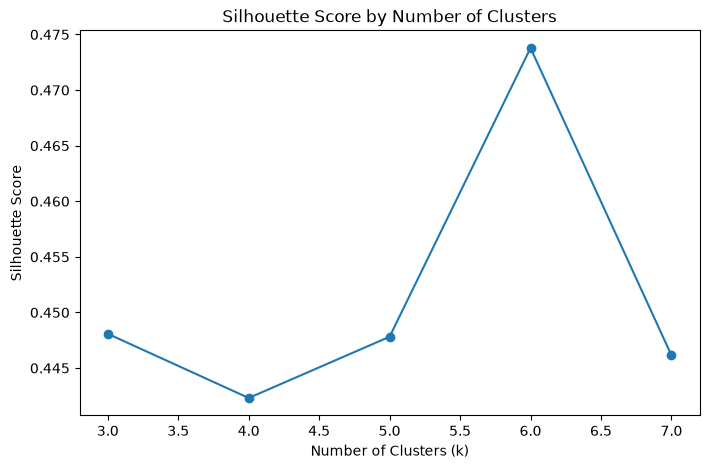

In [40]:
#Using silhouette score to decide the optimal number of clusters

scores = []
k_values = range(3, 8)

for k in k_values:
    kmeans_runner = KMeansCluster(n_clusters=k)
    cluster_df = kmeans_runner.fit(pca_df)

    score = silhouette_score(
        pca_df[["PCA1", "PCA2"]],
        cluster_df["cluster"]
    )

    scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

- Plotting of the 6 clusters, with PCA loadings

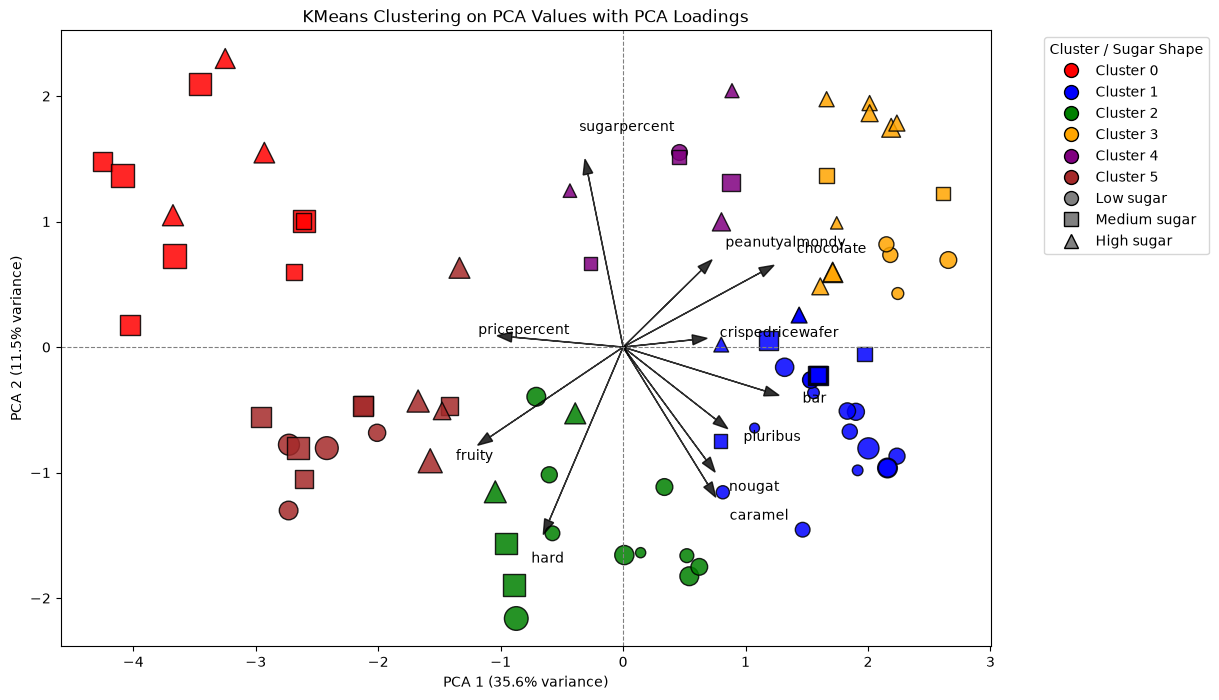

In [41]:
kmeans_runner = KMeansCluster(n_clusters=6)

cluster_df = kmeans_runner.fit(pca_df)

kmeans_runner.plot(
    pca_model=pca_runner.pca_model,
    input_cols=pca_runner.input_cols,
    explained_variance_ratio=pca_runner.explained_variance_ratio_,
    show_loadings=True,
    use_sugar_shapes=True,
    use_winpercent_size=True
)

- Investigating the attributes variation for each cluster
- Cluster 0 appears to be the most successful cluster, regarding win%
- Cluser 0 also displays the hight sugar percent among clusters and it is 2nd in price percent
- Cluster 0,2,5 depicting the higher win% are all characterized by the presence of chocolate, peanutyalmondy and total absence of fruit. 0,5 got also crispedricewafer
- The 3 bottom tier clusters on win percent display lower prices vs the top 3 tier clusters

In [ ]:
cluster_df[["competitorname", "PCA1", "PCA2", "cluster"]].sort_values("cluster")

cluster_summary = (
    cluster_df
    .join(df[cols_to_encode])
    .groupby("cluster")[cols_to_encode + ["sugarpercent", "pricepercent", "winpercent"]]
    .mean()
)

cluster_summary.sort_values(by="winpercent", ascending=False).to_excel("cluster_summary.xlsx")
cluster_summary.sort_values(by="winpercent", ascending=False)

- Investigating the initial attributes for each cluster

In [43]:
# Add cluster labels from PCA/KMeans back to the original dataframe
df_clustered = df.copy()
df_clustered["cluster"] = cluster_df["cluster"]

# Columns to inspect per candy
inspect_cols = (
    ["cluster", "competitorname", "winpercent", "sugarpercent", "pricepercent"]
    + cols_to_encode
)

cluster_samples = df_clustered[inspect_cols].sort_values(
    ["cluster", "winpercent"],
    ascending=[True, False]
)

cluster_samples[cluster_samples["cluster"] == 1]

,cluster,competitorname,winpercent,sugarpercent,pricepercent,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus
68,1,Starburst,67.037628,0.151,0.220,0,1,0,0,0,0,0,0,1
66,1,Sour Patch Kids,59.863998,0.069,0.116,0,1,0,0,0,0,0,0,1
18,1,Haribo Gold Bears,57.119740,0.465,0.465,0,1,0,0,0,0,0,0,1
73,1,Swedish Fish,54.861111,0.604,0.755,0,1,0,0,0,0,0,0,1
31,1,Lifesavers big ring gummies,52.911392,0.267,0.279,0,1,0,0,0,0,0,0,0
67,1,Sour Patch Tricksters,52.825947,0.069,0.116,0,1,0,0,0,0,0,0,1
20,1,Haribo Sour Bears,51.412430,0.465,0.465,0,1,0,0,0,0,0,0,1
78,1,Trolli Sour Bites,47.173229,0.313,0.255,0,1,0,0,0,0,0,0,1
80,1,Twizzlers,45.466282,0.220,0.116,0,1,0,0,0,0,0,0,0
82,1,Welch's Fruit Snacks,44.375519,0.313,0.313,0,1,0,0,0,0,0,0,1


- Each cluster presents a potential market opportunity (different types of candy)
- Clusters that have high mean win%, provide small opportunity for new product to succeed
- However besides mean winpercent, the variance of win% within a cluster affects opportunity
- Clusters with low win% but having specific outlier products with high win% may also provide small opportunity for new product

- Attempted to quantify **market opportunity** for each cluster with an index:  
  *market index* = `cluster_size × (100 - mean_cluster_win%) × variance_win% / mean_win%`

In [ ]:
#Creating an index in order to quantify the potential market opportunity for each cluster
for cluster in cluster_samples['cluster'].unique():
    print(cluster)
    sum_cluster = int(cluster_samples[cluster_samples['cluster']==cluster].shape[0])
    mean_winpercent = cluster_samples[cluster_samples['cluster']==cluster]['winpercent'].mean()
    sd_mean = cluster_samples[cluster_samples['cluster']==cluster]['winpercent'].agg(
          mean_win="mean",
          sd_win="std"
      )
    #Using the standard deviation and mean in order to check how win% spreads within the cluster.
    win_index = sd_mean["sd_win"] / sd_mean["mean_win"]
    print(f"Opportunity Index: {sum_cluster * (100 - mean_winpercent)}")
    #Inducing the win_index into the market index to account for the spread of win% within the cluster.
    market_index = sum_cluster * (100 - mean_winpercent) * win_index
    print(sd_mean["sd_win"], sd_mean["mean_win"])
    print(f"Cluster: {cluster}, market_index: {market_index}")

0
Opportunity Index: 407.13961399999994
12.59143056326998 62.987307818181826
Cluster: 0, market_index: 81.38893940403882
1
Opportunity Index: 1368.782908
11.125213694782762 42.967378833333335
Cluster: 1, market_index: 354.40845512904684
2
Opportunity Index: 638.567392
16.836032546226267 54.38804342857143
Cluster: 2, market_index: 197.67104526917186
3
Opportunity Index: 853.942437
9.513871929199738 43.070504199999995
Cluster: 3, market_index: 188.627905139005
4
Opportunity Index: 421.29459399999996
8.083344304300086 39.81505800000001
Cluster: 4, market_index: 85.53219379568192
5
Opportunity Index: 533.3481310000001
11.358461199581214 61.90370492857142
Cluster: 5, market_index: 97.86189790777136


- As only the win percent is provided for each candy, without knowing vs which candy each candy won,
we can infer the possibility of each candy to win vs a candy within the same cluster using probabilities

- For this reason a proxy was constructed as following: 
    - `P(A>B) = P(A) / P(A) + P(B)`
    - `P(A) = P(A>B) + P(A>C) / num_cluster_size`


In [45]:
#Proxy implementation

def proxy_win_index(df):

    win_percent = df["winpercent"].values

    probs = []

    for i, i_row in enumerate(win_percent):
        
        pairwise_probs = []

        for j, j_row in enumerate(win_percent):
            
            if i != j:
                p = i_row / (i_row + j_row)
                pairwise_probs.append(p)

        probs.append(np.mean(pairwise_probs))

    df = df.copy()
    df["proxy_win_index"] = probs

    return df

win_df = (
    cluster_samples.groupby("cluster", group_keys=False)
      .apply(proxy_win_index)
)

In [14]:
cluster_samples['proxy_win_index'] = win_df['proxy_win_index']

In [15]:
#Inspecting the proxy win index for a specific cluster
cluster_samples[cluster_samples["cluster"] == 2].sort_values(by="proxy_win_index", ascending=False)[["competitorname", "winpercent", "proxy_win_index"]]

,competitorname,winpercent,proxy_win_index
51,Reese's Miniatures,81.866257,0.618181
53,Reese's pieces,73.434990,0.590711
32,Peanut butter M&M's,71.465050,0.583759
47,Peanut M&Ms,69.483788,0.576542
33,M&M's,66.574585,0.565512
27,Junior Mints,57.219250,0.526092
22,Hershey's Kisses,55.375454,0.517517
35,Milk Duds,55.064072,0.516040
3,One quarter,46.116505,0.469594
76,Tootsie Roll Midgies,45.736748,0.467435


- Investigating the sd for the proxy win index for each

   cluster  sd_proxy  var_proxy   n
0        0  0.058554   0.003429  11
1        1  0.068991   0.004760  24
2        2  0.088395   0.007814  14
3        3  0.057978   0.003361  15
4        4  0.056213   0.003160   7
5        5  0.048078   0.002311  14


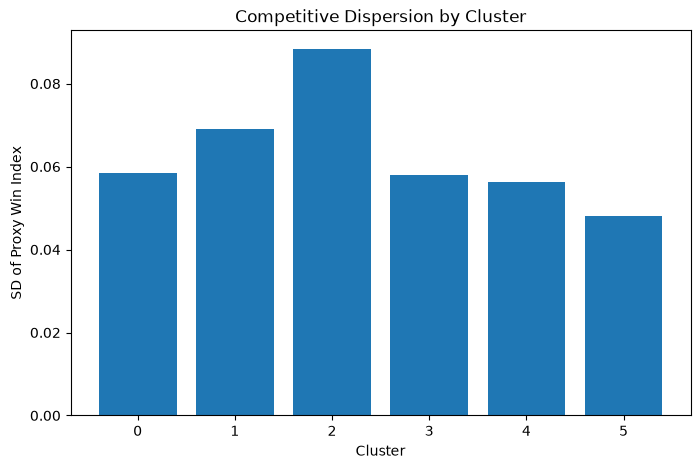

In [16]:
#Bar plot of the proxy win index by cluster
cluster_competitiveness = (
    cluster_samples.groupby("cluster")["proxy_win_index"]
      .agg(
          sd_proxy="std",
          var_proxy="var",
          n="count"
      )
      .reset_index()
)

print(cluster_competitiveness)

cluster_competitiveness = (
    cluster_samples.groupby("cluster")["proxy_win_index"]
      .std()
      .reset_index(name="sd_proxy")
)

plt.figure(figsize=(8,5))

plt.bar(
    cluster_competitiveness["cluster"],
    cluster_competitiveness["sd_proxy"]
)

plt.xlabel("Cluster")
plt.ylabel("SD of Proxy Win Index")
plt.title("Competitive Dispersion by Cluster")

plt.show()

- Observing the different attributes of each cluster
- Cluster 0 and 5 are most similar followed by cluster 2
- cluster 0 characterized by the presence of nougat and caramel while these are absent in cluster 5
- Cluster 2 closer to 0 and 5, but got pluribus candies instead of bar, also absent nougat and caramel
- Cluster 1, 3 and 4 are characterized by the absence of chocolate and presence of fruit

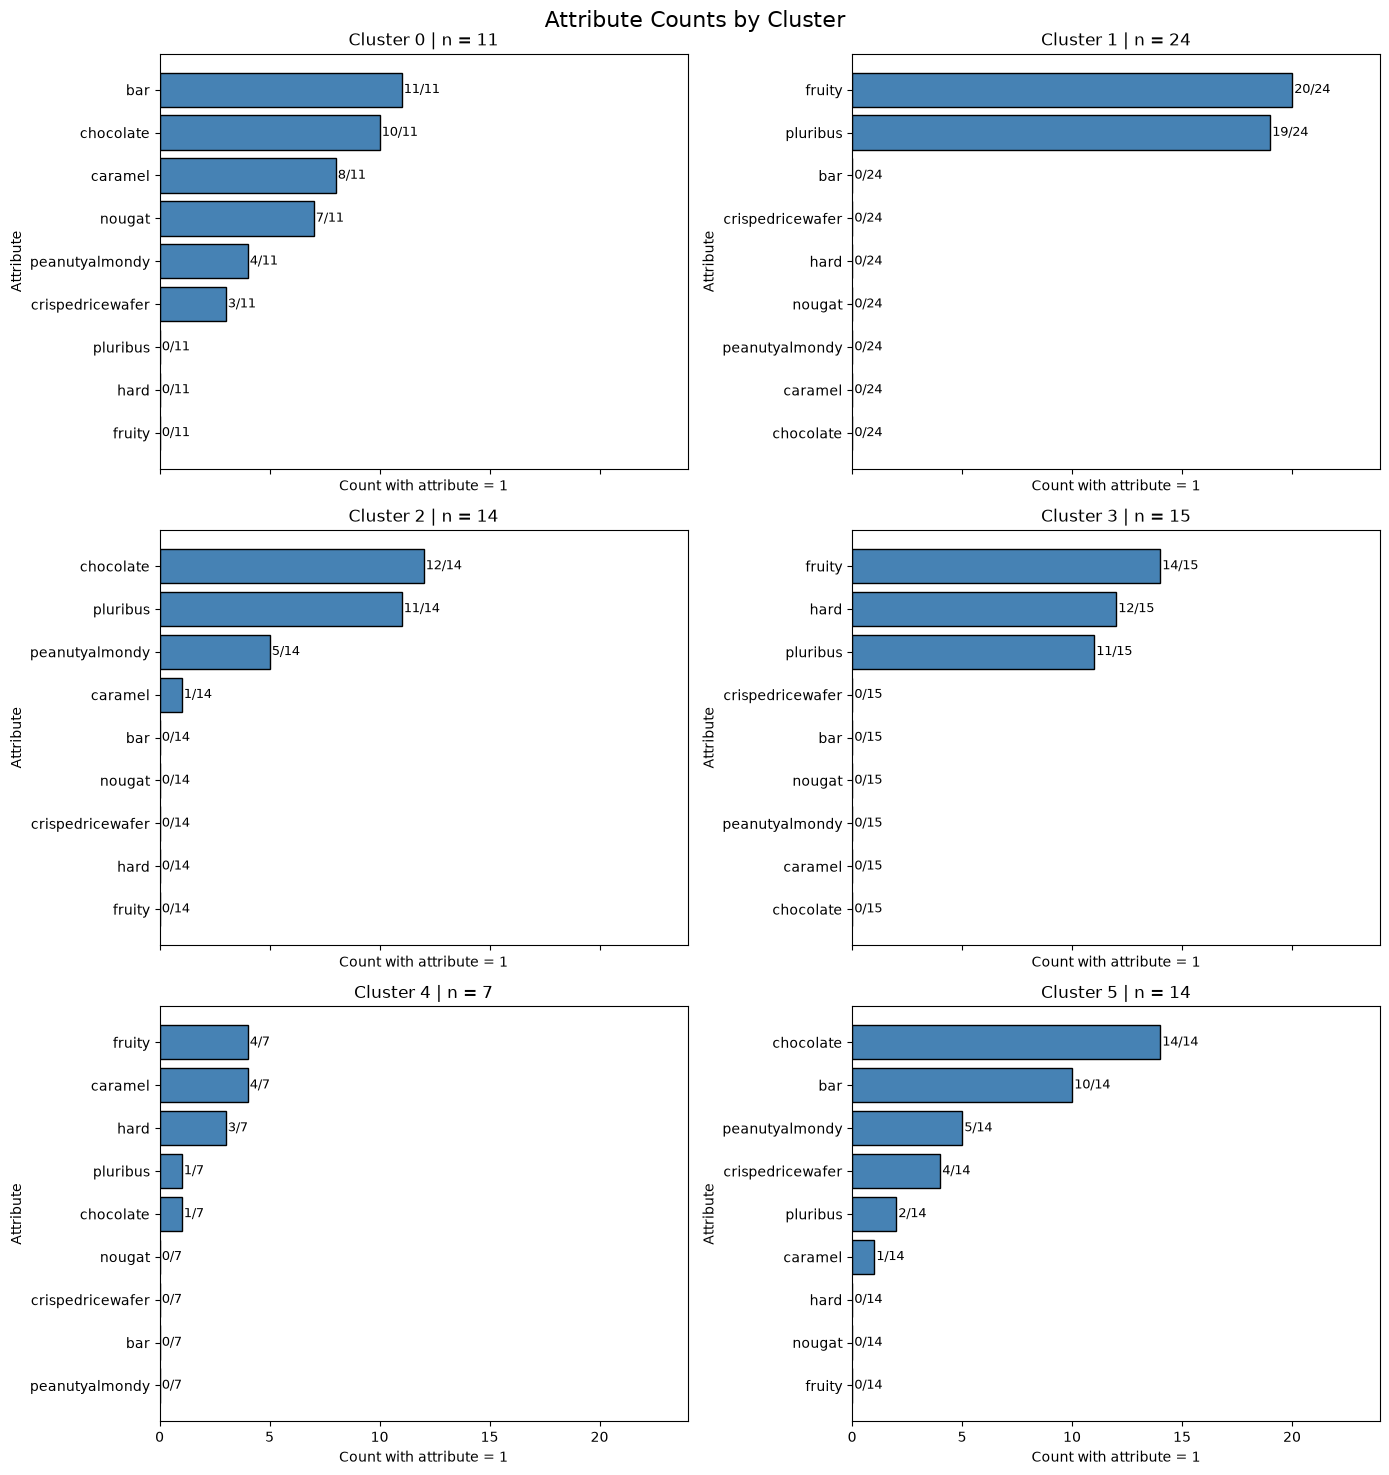

In [17]:
# Safely attach cluster labels
df_clustered = df.merge(
    cluster_df[["competitorname", "cluster"]],
    on="competitorname",
    how="inner"
)

cluster_sizes = (
    df_clustered
    .groupby("cluster")
    .size()
    .rename("cluster_size")
)

binary_counts_1 = (
    df_clustered
    .groupby("cluster")[cols_to_encode]
    .sum()
)

cluster_ids = sorted(df_clustered["cluster"].unique())

n_clusters = len(cluster_ids)
n_cols = 2
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows),
    sharex=True
)

axes = np.array(axes).reshape(-1)

max_cluster_size = cluster_sizes.max()

for ax, cluster_id in zip(axes, cluster_ids):
    cluster_size = cluster_sizes.loc[cluster_id]
    attribute_counts = binary_counts_1.loc[cluster_id].sort_values(ascending=True)

    ax.barh(
        attribute_counts.index,
        attribute_counts.values,
        color="steelblue",
        edgecolor="black"
    )

    ax.set_xlim(0, max_cluster_size)
    ax.set_title(f"Cluster {cluster_id} | n = {cluster_size}")
    ax.set_xlabel("Count with attribute = 1")
    ax.set_ylabel("Attribute")

    for i, value in enumerate(attribute_counts.values):
        ax.text(
            value + 0.1,
            i,
            f"{int(value)}/{cluster_size}",
            va="center",
            fontsize=9
        )

# Hide empty subplots if cluster count is odd
for ax in axes[len(cluster_ids):]:
    ax.axis("off")

fig.suptitle("Attribute Counts by Cluster", fontsize=16)
plt.tight_layout()
plt.show()

- Clusters 0,2,5 are the most successful ones on terms of win%
- Cluster 1 and 2 display the highest market opportunity based on the market proxy
- Investigating 0,2,5 clusters highlighted that the presence of chocolate and the absence of fruit are the most significant factors directing win%
- So conducting Linear Regression on win% just as sanity check to validate the findings of this research so far, regarding the most significant factors affecting win%

- Linear Regression results are contemplating our findings, depicting that chocolate is the dominant factor regarding win%, followed by peanutyalmondy

In [86]:
attributes = cols_to_encode + ["sugarpercent", "pricepercent"]
y = df["winpercent"]

# Using the encoded values of the categorical features and the numerical features
Xs = freq_df[attributes]
scaler = StandardScaler()
Xs = scaler.fit_transform(Xs)
lr = LinearRegression().fit(Xs, y)

imp = (pd.DataFrame({
        "std_coef": lr.coef_,
        "simple_corr": [freq_df[f].corr(y) for f in attributes]},
        index=attributes)
       .sort_values("std_coef", ascending=False))
imp = imp * (-1)
print(imp.round(2).sort_values("std_coef", ascending=False))

                  std_coef  simple_corr
chocolate             9.79         0.64
fruity                4.68        -0.38
peanutyalmondy        3.74         0.41
crispedricewafer      2.45         0.32
pricepercent          1.68        -0.35
caramel               0.83         0.21
pluribus              0.43         0.25
nougat                0.22         0.20
bar                   0.19         0.43
hard                 -2.35        -0.31
sugarpercent         -2.55        -0.23
